## Squeezed states visualizer

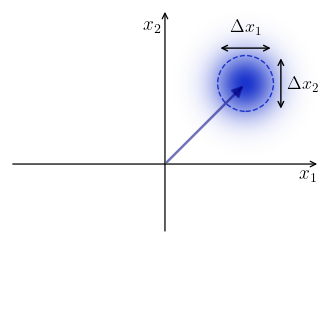

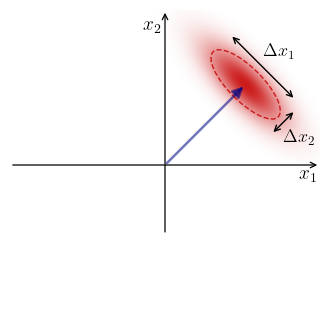

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

os.makedirs("fig", exist_ok=True)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})


def add_variance_arrows(ax, cx, cy, a, b, phi, gap=0.12,
                         label_major=r"$\Delta x_1$",
                         label_minor=r"$\Delta x_2$",
                         color="black", lw=1.0, fontsize=13, zorder=5):
    """
    Double-headed arrows spanning the 1-sigma ellipse along its two
    principal axes, offset just outside the ellipse (like Delta x1/Delta x2
    in the coherent/squeezed reference figure).
    """
    u_major = np.array([np.cos(phi), np.sin(phi)])
    u_minor = np.array([-np.sin(phi), np.cos(phi)])
    center = np.array([cx, cy])

    # major-axis arrow, offset outward along the minor direction
    off = center + u_minor * (b + gap)
    p1, p2 = off - u_major * a, off + u_major * a
    ax.annotate("", xy=p2, xytext=p1, zorder=zorder,
                arrowprops=dict(arrowstyle="<->", lw=lw, color=color))
    lab_pos = off + u_minor * 0.35
    ax.text(*lab_pos, label_major, fontsize=fontsize, ha="center", va="center",
            zorder=zorder)

    # minor-axis arrow, offset outward along the major direction
    off2 = center + u_major * (a + gap)
    p3, p4 = off2 - u_minor * b, off2 + u_minor * b
    ax.annotate("", xy=p4, xytext=p3, zorder=zorder,
                arrowprops=dict(arrowstyle="<->", lw=lw, color=color))
    lab_pos2 = off2 + u_major * 0.35
    ax.text(*lab_pos2, label_minor, fontsize=fontsize, ha="center", va="center",
            zorder=zorder)

def plot_phase_space_state(r=0.0, phi=0.0, alpha=0.0 + 0.0j,
                            ax=None, lim=2.5, s0=0.45, gamma=1.6,
                            res=400, color=(0.80, 0.10, 0.10),
                            show_variance_arrows=False):
    """
    Draw a phase-space (Wigner) representation of a displaced squeezed
    vacuum state as a smooth Gaussian glow (no banding).

    r      : squeezing parameter (0 -> vacuum, circular blob)
    phi    : squeezing angle (radians)
    alpha  : complex displacement (x1 + i*x2)
    s0     : base 1-sigma width (vacuum radius); squeezed axes scale by e^{+/-r} (changes size of the blob)
    gamma  : >1 shrinks the solid-looking core / sharpens falloff (try 1.3-1.6
                if it still looks too solid); <1 does the opposite.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.4, 3.4))

    a = s0 * np.exp(r)
    b = s0 * np.exp(-r)
    cx, cy = alpha.real, alpha.imag

    xs = np.linspace(-lim, lim, res)
    ys = np.linspace(-lim, lim, res)
    X, Y = np.meshgrid(xs, ys)
    dx, dy = X - cx, Y - cy
    xr = dx * np.cos(phi) + dy * np.sin(phi)
    yr = -dx * np.sin(phi) + dy * np.cos(phi)
    Z = np.exp(-0.5 * ((xr / a) ** 2 + (yr / b) ** 2))
    A = np.clip(Z, 0, 1) ** gamma

    rgba = np.zeros((res, res, 4))
    rgba[..., 0], rgba[..., 1], rgba[..., 2] = color
    rgba[..., 3] = A
    ax.imshow(rgba, extent=[-lim, lim, -lim, lim], origin="lower", zorder=1)

    core = Ellipse((cx, cy), width=2 * a, height=2 * b,
                    angle=np.degrees(phi), facecolor="none",
                    edgecolor=color, linestyle="--",
                    linewidth=1.0, zorder=2)
    ax.add_patch(core)

    '''ax.annotate("", xy=(lim, 0), xytext=(-lim, 0), zorder=4,
                arrowprops=dict(arrowstyle="->", lw=0.9, color="black"))
    ax.annotate("", xy=(0, lim), xytext=(0, -lim), zorder=4,
                arrowprops=dict(arrowstyle="->", lw=0.9, color="black"))
    ax.text(lim - 0.05, -0.22, r"$x_1$", fontsize=14, ha="right", zorder=4)
    ax.text(-0.35, lim - 0.10, r"$x_2$", fontsize=14, va="top", zorder=4)'''


    y_low = 0.45 * lim   # <-- NEW: shorter tail below the origin (tune 0.4-0.6 to taste)

    # axes
    ax.annotate("", xy=(lim, 0), xytext=(-lim, 0), zorder=4,
                arrowprops=dict(arrowstyle="->", lw=0.9, color="black"))
    ax.annotate("", xy=(0, lim), xytext=(0, -y_low), zorder=4,          # <-- was -lim
                arrowprops=dict(arrowstyle="->", lw=0.9, color="black"))
    ax.text(lim - 0.05, -0.22, r"$x_1$", fontsize=14, ha="right", zorder=4)
    ax.text(-0.35, lim - 0.10, r"$x_2$", fontsize=14, va="top", zorder=4)

    # displacement arrow: blue, reduced opacity, drawn on top
    if abs(alpha) > 1e-6:
        ax.annotate("", xy=(cx, cy), xytext=(0, 0), zorder=6,
                    arrowprops=dict(arrowstyle="-|>", lw=1.8,
                                    color="#000080", alpha=0.55,
                                    mutation_scale=16))

    if show_variance_arrows:
        add_variance_arrows(ax, cx, cy, a, b, phi)

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.axis("off")

    return ax

# --- Figure 1: vacuum state, centered at origin ---
alpha = 1.3 + 1.3j
fig1, ax1 = plt.subplots(figsize=(3.4, 3.4))
plot_phase_space_state(r=0.0, phi=0.0, alpha=alpha, ax=ax1,
                        show_variance_arrows=True, color=(0.10, 0.20, 0.80))
plt.tight_layout()
plt.savefig("fig/vacuum_state.png", dpi=300, transparent=True)
#plt.savefig("fig/vacuum_state.svg", transparent=True)
plt.show()

# --- Figure 2: displaced squeezed vacuum, r=0.5, phi=-pi/4, in Q1 ---
r = 0.5
phi = -np.pi / 4

fig2, ax2 = plt.subplots(figsize=(3.4, 3.4))
plot_phase_space_state(r=r, phi=phi, alpha=alpha, ax=ax2,
                        show_variance_arrows=True)
plt.tight_layout()
plt.savefig("fig/displaced_squeezed_state.png", dpi=300, transparent=True)
#plt.savefig("fig/displaced_squeezed_state.svg", transparent=True)
plt.show()

with text boxes

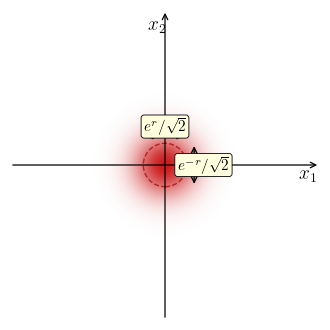

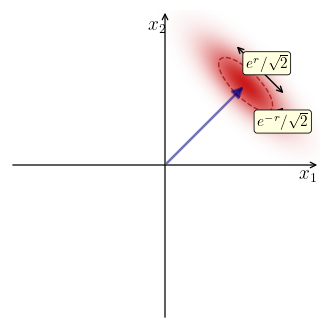

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

os.makedirs("fig", exist_ok=True)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})


def add_variance_arrows(ax, cx, cy, a, b, phi, gap=0.12,
                         label_major=r"$e^{r}/\sqrt{2}$",
                         label_minor=r"$e^{-r}/\sqrt{2}$",
                         color="black", lw=1.0, fontsize=11, zorder=5):
    """
    Double-headed arrows spanning the 1-sigma ellipse along its two
    principal axes, offset just outside the ellipse (like Delta x1/Delta x2
    in the coherent/squeezed reference figure). These are the two widths
    whose product saturates the Heisenberg uncertainty relation.
    """
    u_major = np.array([np.cos(phi), np.sin(phi)])
    u_minor = np.array([-np.sin(phi), np.cos(phi)])
    center = np.array([cx, cy])

    # major-axis arrow, offset outward along the minor direction
    off = center + u_minor * (b + gap)
    p1, p2 = off - u_major * a, off + u_major * a
    ax.annotate("", xy=p2, xytext=p1, zorder=zorder,
                arrowprops=dict(arrowstyle="<->", lw=lw, color=color))
    lab_pos = off + u_minor * 0.15
    ax.text(*lab_pos, label_major, fontsize=fontsize, ha="center", va="center",
            zorder=zorder,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="lightyellow",
                       edgecolor="black", linewidth=0.6))

    # minor-axis arrow, offset outward along the major direction
    off2 = center + u_major * (a + gap)
    p3, p4 = off2 - u_minor * b, off2 + u_minor * b
    ax.annotate("", xy=p4, xytext=p3, zorder=zorder,
                arrowprops=dict(arrowstyle="<->", lw=lw, color=color))
    lab_pos2 = off2 + u_major * 0.15
    ax.text(*lab_pos2, label_minor, fontsize=fontsize, ha="center", va="center",
            zorder=zorder,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="lightyellow",
                       edgecolor="black", linewidth=0.6))


def plot_phase_space_state(r=0.0, phi=0.0, alpha=0.0 + 0.0j,
                            ax=None, lim=2.5, s0=0.35, gamma=1.0,
                            res=400, color=(0.80, 0.10, 0.10),
                            show_variance_arrows=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.4, 3.4))

    a = s0 * np.exp(r)
    b = s0 * np.exp(-r)
    cx, cy = alpha.real, alpha.imag

    xs = np.linspace(-lim, lim, res)
    ys = np.linspace(-lim, lim, res)
    X, Y = np.meshgrid(xs, ys)
    dx, dy = X - cx, Y - cy
    xr = dx * np.cos(phi) + dy * np.sin(phi)
    yr = -dx * np.sin(phi) + dy * np.cos(phi)
    Z = np.exp(-0.5 * ((xr / a) ** 2 + (yr / b) ** 2))
    A = np.clip(Z, 0, 1) ** gamma

    rgba = np.zeros((res, res, 4))
    rgba[..., 0], rgba[..., 1], rgba[..., 2] = color
    rgba[..., 3] = A
    ax.imshow(rgba, extent=[-lim, lim, -lim, lim], origin="lower", zorder=1)

    core = Ellipse((cx, cy), width=2 * a, height=2 * b,
                    angle=np.degrees(phi), facecolor="none",
                    edgecolor="firebrick", linestyle="--",
                    linewidth=1.0, zorder=2)
    ax.add_patch(core)

    ax.annotate("", xy=(lim, 0), xytext=(-lim, 0), zorder=4,
                arrowprops=dict(arrowstyle="->", lw=0.9, color="black"))
    ax.annotate("", xy=(0, lim), xytext=(0, -lim), zorder=4,
                arrowprops=dict(arrowstyle="->", lw=0.9, color="black"))
    ax.text(lim - 0.05, -0.22, r"$x_1$", fontsize=14, ha="right", zorder=4)
    ax.text(-0.28, lim - 0.10, r"$x_2$", fontsize=14, va="top", zorder=4)

    # displacement arrow: blue, reduced opacity, drawn on top
    if abs(alpha) > 1e-6:
        ax.annotate("", xy=(cx, cy), xytext=(0, 0), zorder=6,
                    arrowprops=dict(arrowstyle="-|>", lw=1.8,
                                    color="#000080", alpha=0.55,
                                    mutation_scale=16))

    if show_variance_arrows:
        add_variance_arrows(ax, cx, cy, a, b, phi)

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.axis("off")

    return ax


# --- Figure 1: vacuum state, centered at origin ---
fig1, ax1 = plt.subplots(figsize=(3.4, 3.4))
plot_phase_space_state(r=0.0, phi=0.0, alpha=0.0 + 0.0j, ax=ax1,
                        show_variance_arrows=True)
plt.tight_layout()
plt.savefig("fig/vacuum_state.png", dpi=300, transparent=True)
plt.savefig("fig/vacuum_state.svg", transparent=True)
plt.show()

# --- Figure 2: displaced squeezed vacuum, r=0.5, phi=-pi/4, in Q1 ---
r = 0.5
phi = -np.pi / 4
alpha = 1.3 + 1.3j

fig2, ax2 = plt.subplots(figsize=(3.4, 3.4))
plot_phase_space_state(r=r, phi=phi, alpha=alpha, ax=ax2,
                        show_variance_arrows=True)
plt.tight_layout()
plt.savefig("fig/displaced_squeezed_state.png", dpi=300, transparent=True)
plt.savefig("fig/displaced_squeezed_state.svg", transparent=True)
plt.show()